В нашем распоряжении есть данные о 8950 держателях кредитных карт одного из банков Нью-Йорка. Банк собрал достаточно много данных об этих людях и о том, как они пользовались кредитными картами за последние полгода.

Маркетологи хотят запустить рекламную кампанию, однако для этого необходимо произвести сегментацию клиентов, чтобы сделать акционное предложение более персонализированным. Мы попробуем использовать все известные нам методы кластеризации и посмотрим на получившиеся результаты.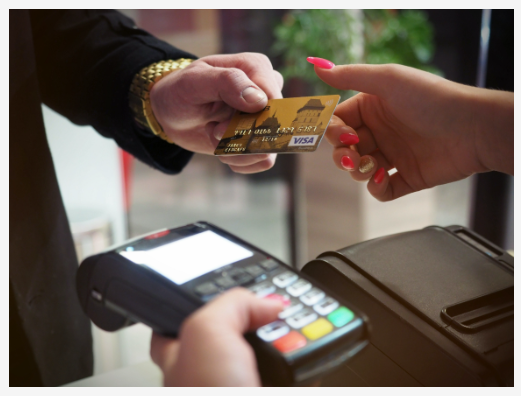

Информация о клиентах:
- CUST_ID — идентификационный номер держателя карты;
- BALANCE — баланс, доступный для совершения покупок;
- BALANCEFREQUENCY — как часто обновляется показатель баланса (1 — часто, 0 — нечасто);
- PURCHASES — количество покупок, оплаченных со счёта;
- ONEOFFPURCHASES — максимальная сумма единовременной покупки;
- INSTALLMENTSPURCHASES — сумма покупок, сделанных в рассрочку;
- PURCHASESFREQUENCY — как часто в целом совершаются покупки (1 — часто, 0 — нечасто);
- ONEOFFPURCHASESFREQUENCY — частота совершения единовременных покупок (1 — часто, 0 — нечасто);
- PURCHASESINSTALLMENTSFREQUENCY — частота совершения покупок в рассрочку (1 — часто, 0 — нечасто);
- CASHADVANCEFREQUENCY — частота внесения авансовых платежей;
- CASHADVANCETRX — количество транзакций с авансовыми взносами;
- PURCHASESTRX — количество совершённых транзакций с покупками;
- CREDITLIMIT — кредитный лимит держателя карты;
- PAYMENTS — сумма платежей пользователя;
- MINIMUM_PAYMENTS — сумма минимального платежа пользователя;
- PRCFULLPAYMENT — выплаченный процент от полного платежа;
- TENURE — срок обслуживания кредитной карты.

**Задание 7.2**
Теперь приступим к анализу данных. По традиции начнём его с проверки данных на наличие пропущенных значений. Сколько всего пропусков в данных?

In [1]:
import pandas as pd

df = pd.read_csv('data/CC_GENERAL.csv')
print(f'всего пропусков в данных:{df.isnull().sum().sum()}')

всего пропусков в данных:314


**Задание 7.3**

Заполните все пропуски средними арифметическими для признаков. Каким будет среднее арифметическое для признака MINIMUM_PAYMENTS (если считать после заполнения пропущенных значений)? Округлите результат до двух знаков после точки-разделителя.

In [2]:
df.fillna(df.mean(numeric_only=True), inplace = True)

print('среднее арифметическое для признака MINIMUM_PAYMENTS:', round((df['MINIMUM_PAYMENTS'].mean()),2))

среднее арифметическое для признака MINIMUM_PAYMENTS: 864.21


**Задание 7.4**
Теперь нормализуйте данные с помощью StandardScaler(). Для получившейся матрицы нормализованных признаков выведите самое первое значение в самой первой строке (X_norm[0][0]). Округлите до двух знаков после точки-разделителя.

In [3]:
from sklearn.preprocessing import StandardScaler

# Удалим признак CUST_ID
df.drop('CUST_ID', axis = 1, inplace = True)
X = df.values
scaler = StandardScaler()
scaler.fit(X)
X_norm = scaler.transform(X)
print(round((X_norm[0][0]),2))

-0.73


**Задание 7.5**
Теперь можем приступать к кластеризации. Начнём с самого простого и популярного метода — k-means. Для того чтобы его применить, необходимо узнать число кластеров. Наилучший способ сделать это — применить коэффициент силуэта. Найдите с его помощью оптимальное количество кластеров, перебрав диапазон от 2 до 9 включительно. В этом и следующем заданиях для параметра random_state возьмём значение 42, параметр init='random'.

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_in

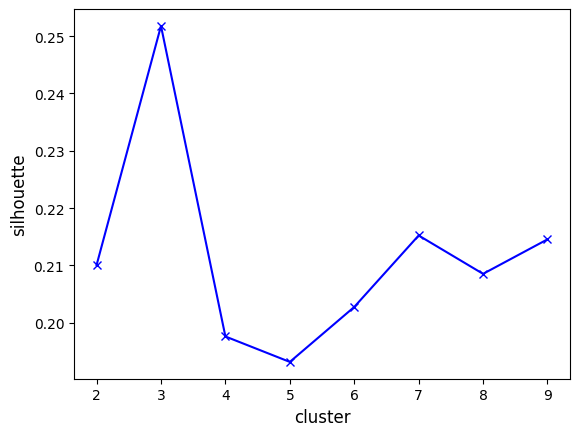

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def get_silhouette(cluster_num, df):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(df)
    silhouette = silhouette_score(df, k_means.labels_, metric='euclidean')
    return silhouette
from sklearn.metrics import silhouette_score
silhouettes = []
for i in range(2, 10):
    silhouettes.append(get_silhouette(i ,X_norm))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(2, 10)], silhouettes, 'xb-');

*Оптимальное количество кластеров 3*

**Задание 7.6**
Теперь реализуем непосредственно кластеризацию k-means с оптимальным количеством кластеров, которое мы определили в предыдущем задании.

Сколько человек оказалось в самой малочисленной группе?

In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, init='random')
kmeans.fit(X_norm)
df.loc[:, 'label'] = kmeans.labels_
df.label.value_counts().min()

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


1252

**Задание 7.7**
Попробуем применить DBSCAN. Для начала реализуйте его с параметрами по умолчанию.

Сколько кластеров было выделено?

In [6]:
from sklearn.cluster import DBSCAN
import numpy as np


clustering = DBSCAN().fit(X_norm)
clusters = clustering.labels_
print('кластеров выделено:', len(set(clusters)) - (1 if -1 in clusters else 0))

кластеров выделено: 38


**Задание 7.8**
В предыдущем задании получилось очень много кластеров. Возможно, это случилось потому, что мы взяли параметры по умолчанию, а результат алгоритма DBSCAN, как вы помните, очень чувствителен к ним.

Давайте попробуем с помощью цикла перебрать параметр eps по значениям, заданным как np.arange(0.1,3,0.2), а параметр min_samples — по значениям, заданным как range(1,20,4). Найдите комбинацию, которая даёт максимальное значение коэффициента силуэта.

In [9]:
siliuette_list_dbscan = []
for eps in np.arange(0.1,3,0.2):
    for min_samples in range(1,20,4):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(X_norm)
        sil_score = silhouette_score(X_norm, dbscan.labels_, metric='euclidean')
        siliuette_list_dbscan.append(get_silhouette(eps, min_samples), sil_score, len(set(dbscan.labels_)))


InvalidParameterError: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0.1 instead.

In [10]:
siliuette_list_dbscan = []
 
for eps in np.arange(0.1,3,0.2):
    for min_sample in range(1,20,4):
        dbscan = DBSCAN(eps=eps, min_samples=min_sample)
        dbscan.fit(X_norm)
        sil_score = silhouette_score(X_norm, dbscan.labels_, metric='euclidean')
        siliuette_list_dbscan.append((eps, min_sample, sil_score, len(set(dbscan.labels_))) )
df_dbscan = pd.DataFrame(siliuette_list_dbscan, columns=['eps', 'min_samples', 'sil_score', 'number_of_clusters'])
df_dbscan.sort_values(by = 'sil_score')

,eps,min_samples,sil_score,number_of_clusters
11,0.5,5,-0.443701,39
16,0.7,5,-0.438837,29
6,0.3,5,-0.424475,42
7,0.3,9,-0.404209,15
30,1.3,1,-0.399305,1536
...,...,...,...,...
74,2.9,17,0.591924,2
66,2.7,5,0.592182,2
73,2.9,13,0.595399,2
72,2.9,9,0.603811,2


In [12]:
print('Комбинация, которая даёт максимальное значение коэффициента силуэта:', df_dbscan.sort_values(by='sil_score', ascending=False).iloc[0].round(2))

Комбинация, которая даёт максимальное значение коэффициента силуэта: eps                   2.90
min_samples           5.00
sil_score             0.62
number_of_clusters    2.00
Name: 71, dtype: float64


**Задание 7.9**
Теперь давайте реализуем агломеративную иерархическую кластеризацию. Переберите количество кластеров в диапазоне от 3 до 9 включительно и найдите то их число, которое будет давать максимальный коэффициент силуэта.

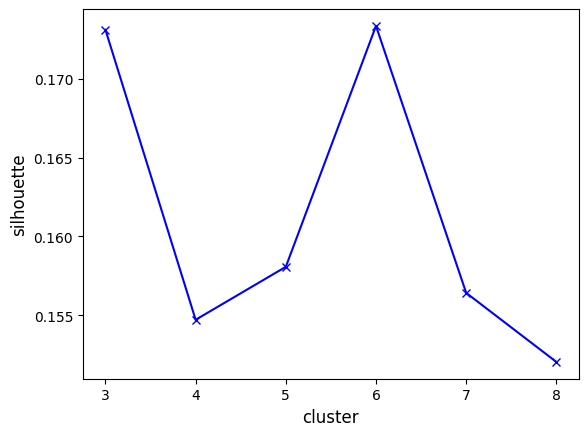

In [126]:
from sklearn.cluster import AgglomerativeClustering

#clustering = AgglomerativeClustering().fit(X)

def get_silhouette(cluster_num, df):
    agglomerativeclustering =  AgglomerativeClustering(n_clusters=cluster_num)
    agglomerativeclustering.fit(df)
    silhouette = silhouette_score(df, agglomerativeclustering.labels_, metric='euclidean')
    return silhouette

from sklearn.metrics import silhouette_score
silhouettes = []
for i in range(3, 9):
    silhouettes.append(get_silhouette(i ,X_norm))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(3, 9)], silhouettes, 'xb-');

**Задание 7.10**
Сколько будет наблюдений в самом многочисленном классе, если мы обучим на наших данных модель агломеративной иерархической кластеризации с количеством кластеров, полученным в предыдущем задании?

In [129]:
agglomerativeclustering =  AgglomerativeClustering(n_clusters=6)
agglomerativeclustering.fit(X_norm)

df.loc[:, 'label'] = agglomerativeclustering.labels_
print('Наблюдений в самом многочисленном классе:', df.label.value_counts().max())

наблюдений в самом многочисленном классе: 3946


Визуализируем результаты **кластеризации k-means**, отобразив два признака — количество покупок и кредитный лимит:

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


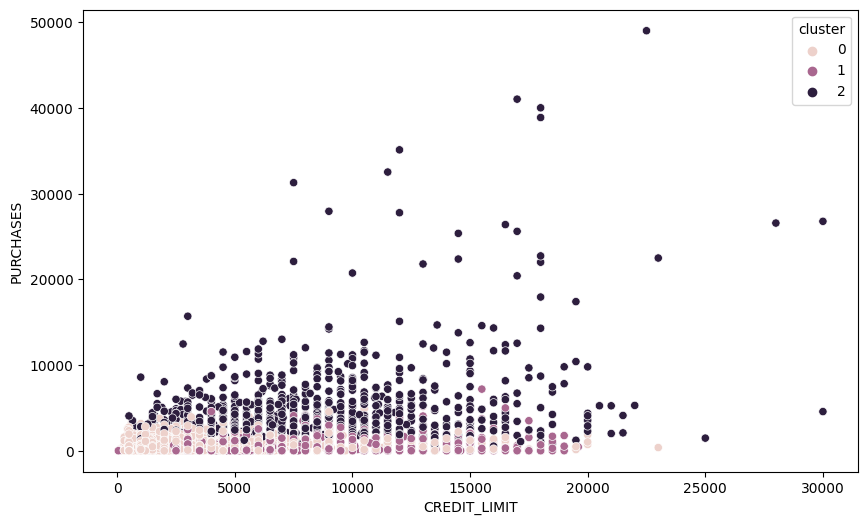

In [131]:
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_norm)
df['cluster'] = kmeans.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()

Визуализируем результаты **кластеризации DBSCAN**, с помощью созданного Датафрейма siliuette_df с максимальным значением силуэта, отобразив два признака — количество покупок и кредитный лимит:

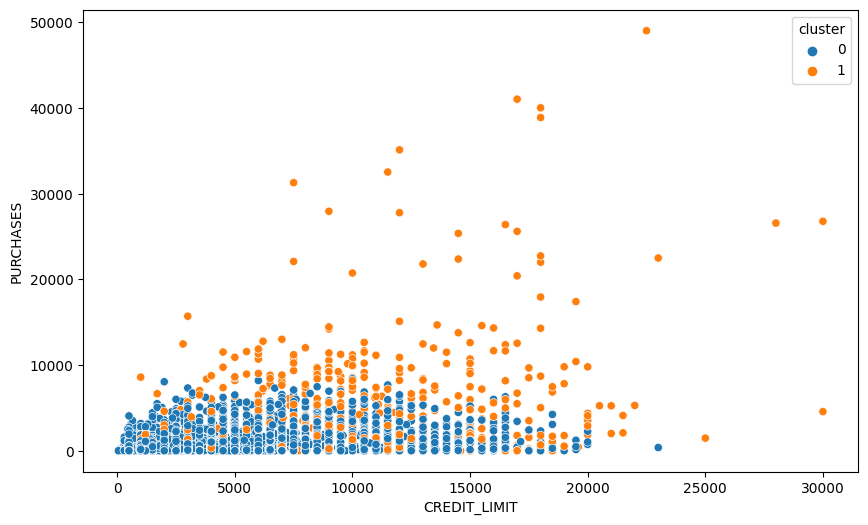

In [172]:
df_clusters = df.copy()
dbscan = DBSCAN(eps=int(siliuette_df.sort_values(by='sil_score', ascending=False).iloc[0][0]), 
                min_samples=int(siliuette_df.sort_values(by='sil_score', ascending=False).iloc[0][1])
)
dbscan.fit(X_norm)
df_clusters['cluster'] = dbscan.labels_
df_clusters['cluster'] = df_clusters['cluster'].apply(lambda x: x if x==0 else 1)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clusters, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()

Визуализируем результаты **агломеративной иерархической кластеризации**, отобразив два признака — количество покупок и кредитный лимит:

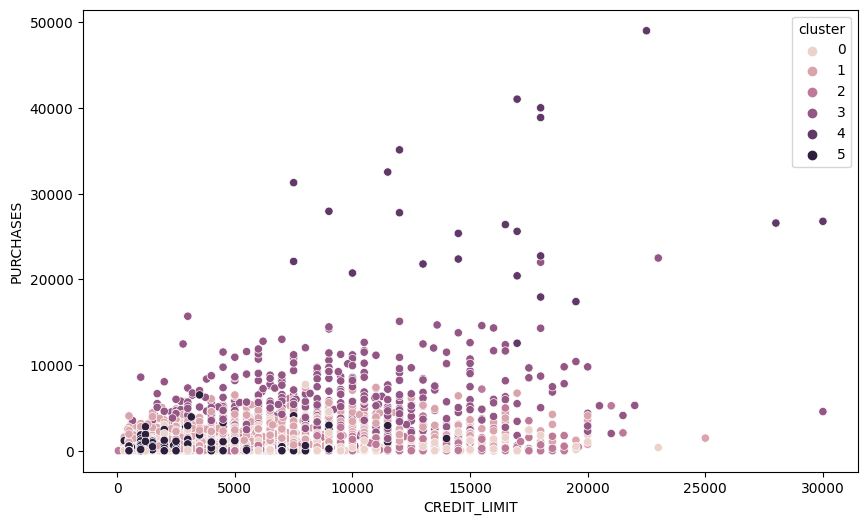

In [144]:
df['cluster'] = agglomerativeclustering.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()

Мы видим, что практически все точки очень плотно сконцентрированы вместе, так что наши результаты с другими алгоритмами вполне предсказуемы.

С точки зрения интерпретации на графике явно выделяется группа тех, кто совершает много покупок по кредитной карте, и тех, кто совершает их меньше и имеет меньший кредитный лимит.

Но, разумеется, это лишь приблизительная интерпретация, ведь качественного разбиения с помощью большинства методов мы так и не получили, а кроме того, здесь мы видим лишь два признака из многих, на основе которых осуществлялась кластеризация.

<p style="border:3px black solid; text-align: left; padding: 10px">Такая проблема с выделением кластеров часто возникает с данными, в которых много признаков. Для того чтобы её решить, можно, например, применять снижение размерности — в следующем модуле мы как раз поработаем с соответствующими методами и научимся преодолевать такие ситуации.